In [19]:
!pip install yfinance

In [20]:
import pandas as pd
import yfinance as yf
import requests
from bs4 import BeautifulSoup
import plotly.graph_objects as go

In [12]:
tesla = yf.Ticker("TSLA")
tesla_data = tesla.history(period="max")

In [13]:
gme = yf.Ticker("GME")
gme_data = gme.history(period="max")

In [14]:
tesla_data.reset_index(inplace=True)
gme_data.reset_index(inplace=True)

In [17]:
tesla_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


In [24]:
gme_data.head()#print the first 5 rows

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620129,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683251,1.687459,1.658002,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662209,1.603295,1.662209,6892800,0.0,0.0


In [33]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"

html_data = requests.get(url).text

In [35]:
# Step 4: Parse the downloaded HTML webpage
# Use BeautifulSoup to turn the raw HTML into a structured format
# This makes it easy to search for tables, rows, and cells
soup = BeautifulSoup(html_data, "html.parser")

In [37]:
# Step 5: Create an empty DataFrame to store Tesla revenue
tesla_revenue = pd.DataFrame(columns=["Date", "Revenue"])

# Step 5b: Loop through all table rows in the webpage
for row in soup.find_all("tr"):              # Look at each <tr> (table row)
    cols = row.find_all("td")                # Get all <td> (cells) in this row
    if len(cols) == 2:                       # Only keep rows with exactly 2 cells
        date = cols[0].text                  # First cell is the Date
        revenue = cols[1].text               # Second cell is the Revenue
        revenue = revenue.replace("$","").replace(",","")  # Remove $ and commas
        # Add the row to tesla_revenue DataFrame using pd.concat
        new_row = pd.DataFrame({"Date":[date], "Revenue":[revenue]})
        tesla_revenue = pd.concat([tesla_revenue, new_row], ignore_index=True)

In [38]:
# Step 6: Clean Tesla revenue table

# Remove any rows where Date or Revenue is missing
tesla_revenue.dropna(inplace=True)

# Remove rows where Revenue is an empty string
tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]

# Show the last 5 rows of the table
tesla_revenue.tail()

,Date,Revenue
61,2010-09-30,31
62,2010-06-30,28
63,2010-03-31,21
65,2009-09-30,46
66,2009-06-30,27


In [39]:
#now for GAMESTOP
# Step 1: Download GameStop revenue page
url_gme = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"

html_data_gme = requests.get(url_gme).text

In [40]:
# Step 2: Parse HTML using BeautifulSoup
soup_gme = BeautifulSoup(html_data_gme, "html.parser")

In [41]:
# Step 3: Create empty DataFrame
gme_revenue = pd.DataFrame(columns=["Date", "Revenue"])

# Step 3b: Loop through table rows and extract data
for row in soup_gme.find_all("tr"):           # Go through each table row
    cols = row.find_all("td")                 # Get all cells in the row
    if len(cols) == 2:                        # Only rows with 2 cells
        date = cols[0].text                   # First cell = Date
        revenue = cols[1].text                # Second cell = Revenue
        revenue = revenue.replace("$","").replace(",","")  # Clean revenue
        # Add row to DataFrame
        new_row = pd.DataFrame({"Date":[date], "Revenue":[revenue]})
        gme_revenue = pd.concat([gme_revenue, new_row], ignore_index=True)

In [42]:
# Step 4: Clean GameStop revenue table
gme_revenue.dropna(inplace=True)              # Remove missing rows
gme_revenue = gme_revenue[gme_revenue['Revenue'] != ""]  # Remove empty revenue
gme_revenue.tail()                            # Show last 5 rows (Q1.5)

,Date,Revenue
61,2010-09-30,31
62,2010-06-30,28
63,2010-03-31,21
65,2009-09-30,46
66,2009-06-30,27


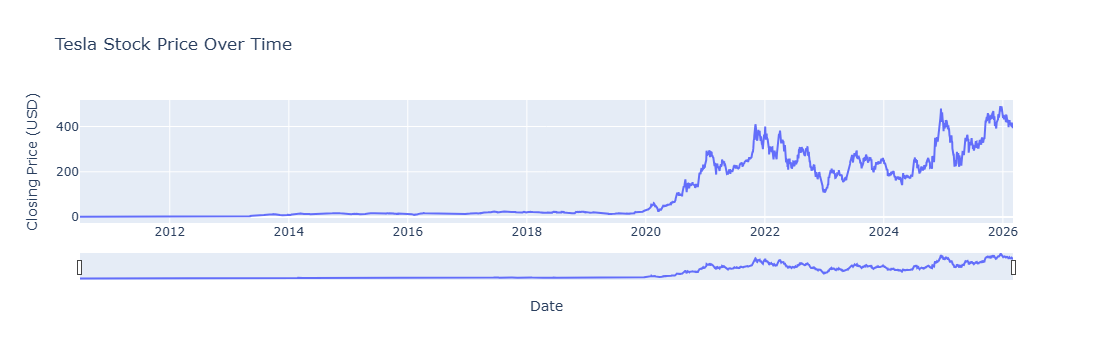

In [43]:
# Tesla Stock Price Chart
fig = go.Figure()  # Create an empty chart

# Add Tesla stock closing price as a line
fig.add_trace(go.Scatter(
    x=tesla_data['Date'],   # X-axis: Dates
    y=tesla_data['Close'],  # Y-axis: Closing stock price
    name="TSLA Stock Price"
))

# Add title and labels
fig.update_layout(
    title="Tesla Stock Price Over Time",
    xaxis_title="Date",
    yaxis_title="Closing Price (USD)",
    xaxis_rangeslider_visible=True  # Interactive zoom
)

fig.show()  # Display the chart

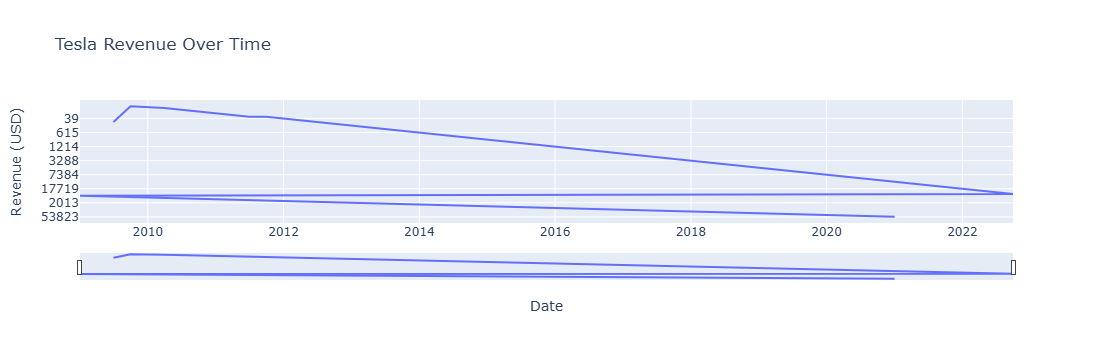

In [44]:
# Tesla Revenue Chart
fig = go.Figure()  # Create a new chart

# Add Tesla revenue as a line
fig.add_trace(go.Scatter(
    x=tesla_revenue['Date'],   # X-axis: Dates
    y=tesla_revenue['Revenue'], # Y-axis: Revenue
    name="Tesla Revenue"
))

# Add title and labels
fig.update_layout(
    title="Tesla Revenue Over Time",
    xaxis_title="Date",
    yaxis_title="Revenue (USD)",
    xaxis_rangeslider_visible=True
)

fig.show()  # Display the chart

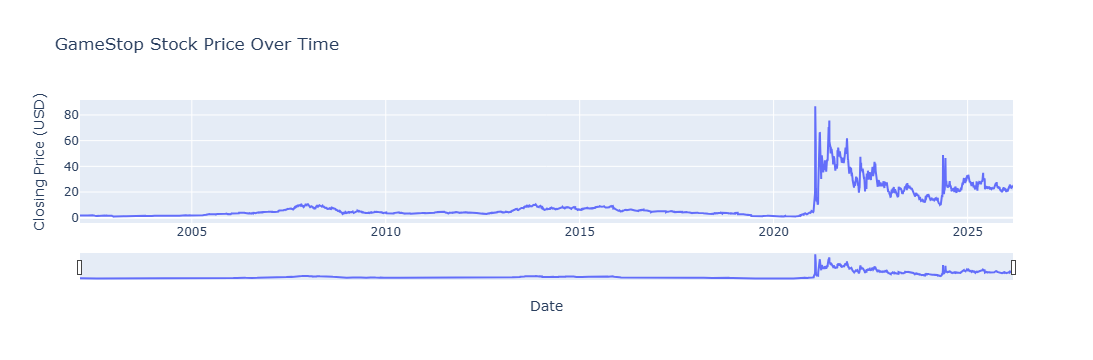

In [45]:
# GameStop Stock Price Chart
fig = go.Figure()  # Empty chart

# Add GameStop stock closing price as a line
fig.add_trace(go.Scatter(
    x=gme_data['Date'],   # Dates
    y=gme_data['Close'],  # Closing price
    name="GME Stock Price"
))

# Add title and labels
fig.update_layout(
    title="GameStop Stock Price Over Time",
    xaxis_title="Date",
    yaxis_title="Closing Price (USD)",
    xaxis_rangeslider_visible=True
)

fig.show()  # Display the chart

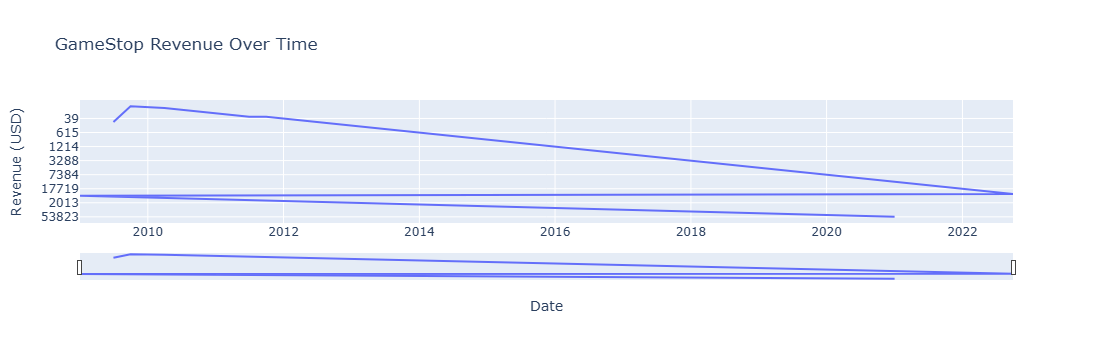

In [46]:
# GameStop Revenue Chart
fig = go.Figure()  # Empty chart

# Add GameStop revenue as a line
fig.add_trace(go.Scatter(
    x=gme_revenue['Date'],    # Dates
    y=gme_revenue['Revenue'], # Revenue
    name="GME Revenue"
))

# Add title and labels
fig.update_layout(
    title="GameStop Revenue Over Time",
    xaxis_title="Date",
    yaxis_title="Revenue (USD)",
    xaxis_rangeslider_visible=True
)

fig.show()  # Display the chart